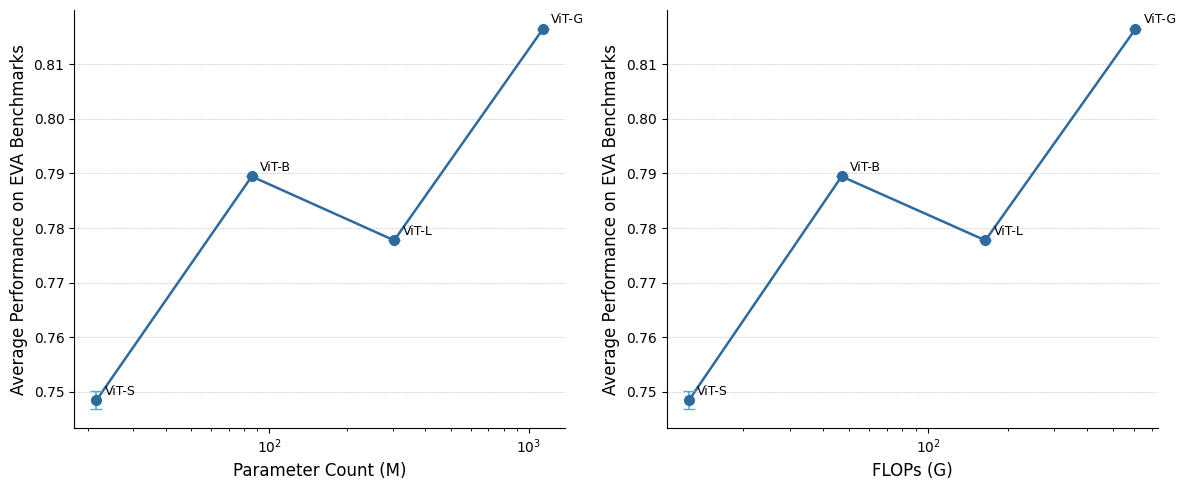

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ── Colors ──────────────────────────────────────────────
COBALT      = '#2D6A9F'
CYAN        = '#48B5C4'
GRAY_TEXT   = '#64748B'

# ── Data ────────────────────────────────────────────────
# Model sizes: Small, Base, Large, Giant
params      = np.array([21.63,  85.73,  303.23,  1135.0])
flops       = np.array([12.46,  47.08,  164.64,  608.35])
avg_perf    = np.array([0.74850522, 0.7894412512, 0.7777434, 0.8164165494])
#std_perf    = np.array([0.00163781186, 0.0, 0.0, 0.0])  # add std for others if available
model_names = ['ViT-S', 'ViT-B', 'ViT-L', 'ViT-G']

# ── Figure: two subplots side by side ───────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, x_vals, xlabel in [
    (ax1, params, 'Parameter Count (M)'),
    (ax2, flops,  'FLOPs (G)')
]:
    # Line
    ax.plot(x_vals, avg_perf, color=COBALT, linewidth=1.8,
            linestyle='-', zorder=2)

    # Error bars + scatter
    ax.errorbar(x_vals, avg_perf, yerr=std_perf,
                fmt='o', color=COBALT, ecolor=CYAN,
                elinewidth=1.2, capsize=4, markersize=7,
                zorder=3)

    # Model name labels
    for i, (x, y, name) in enumerate(zip(x_vals, avg_perf, model_names)):
        ax.annotate(name, (x, y), textcoords='offset points',
                    xytext=(6, 4), fontsize=9, color='black')

    # Axes style
    ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Average Performance on EVA Benchmarks', fontsize=12)
    ax.tick_params(axis='both', labelsize=10)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray')
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_size_performance.png', dpi=300, bbox_inches='tight')
plt.show()
